# 2. The data model — typed records that flow through a tracker

unitrack 2.0 is built around a small set of **immutable, typed
records** backed by `tensordict.tensorclass`. Every interesting
data shape passing between stages of a tracker is one of these
types. This makes the pipeline easy to reason about: a stage's
signature tells you exactly what it consumes and produces.

The five canonical records are:

| Record | Shape | Role |
|---|---|---|
| `Tracklets` | (N,) batched | the tracker's snapshot of live identities |
| `Detections` | (M,) batched | one frame's new observations |
| `FrameContext` | scalar | timing + stream metadata |
| `CostExpression` | (N, M) cost matrix + optional gates | cost producer's output |
| `MatchOutcome` | matched pairs + residual indices | associator's output |

Plus an algebraic variant type `Gate = PerPair | PerCs | PerDs | CostBias`.

We'll walk through each in turn.


In [1]:
import torch
import matplotlib.pyplot as plt

from unitrack.data import (
    CostExpression,
    Detections,
    FrameContext,
    Gate,
    MatchOutcome,
    Tracklets,
)
from unitrack.lifecycle import TrackletStatus

torch.manual_seed(0)


## Tracklets — the snapshot

A `Tracklets` record holds the tracker's view of every live
identity. The reserved fields are common to every tracker:
`id`, `status`, `hits`, `time_since_update`, `age`,
`frame_started`, `frame_last_seen`. User fields (kernel, mask,
bbox, …) are added at construction time and live alongside the
reserved ones.

Status is a `TrackletStatus` enum stored as `int8`:


In [2]:
list(TrackletStatus)


[<TrackletStatus.Tentative: 0>,
 <TrackletStatus.Active: 1>,
 <TrackletStatus.Lost: 2>,
 <TrackletStatus.Removed: 3>]

In [3]:
# Construct three tracklets — two Active, one Tentative.
t = Tracklets(
    id=torch.tensor([10, 11, 12], dtype=torch.int64),
    status=torch.tensor(
        [TrackletStatus.Active, TrackletStatus.Active, TrackletStatus.Tentative],
        dtype=torch.int8,
    ),
    hits=torch.tensor([5, 5, 1], dtype=torch.int32),
    time_since_update=torch.zeros(3, dtype=torch.int32),
    age=torch.tensor([10, 8, 1], dtype=torch.int32),
    frame_started=torch.tensor([0, 2, 9], dtype=torch.int32),
    frame_last_seen=torch.tensor([10, 10, 10], dtype=torch.int32),
    # Two user fields:
    kernel=torch.randn(3, 8),
    position=torch.tensor([[100.0, 50.0], [200.0, 80.0], [50.0, 30.0]]),
    batch_size=[3],
)
print(f"batch_size: {t.batch_size}")
print(f"ids:        {t.id.tolist()}")
print(f"statuses:   {t.status.tolist()}  (0=Tentative, 1=Active)")
print(f"kernel.shape: {t.kernel.shape}")
print(f"position:    {t.position.tolist()}")


batch_size: torch.Size([3])
ids:        [10, 11, 12]
statuses:   [1, 1, 0]  (0=Tentative, 1=Active)
kernel.shape: torch.Size([3, 8])
position:    [[100.0, 50.0], [200.0, 80.0], [50.0, 30.0]]


Snapshots are batch-aware: indexing returns a Tracklets of the
sub-batch, with all fields sliced consistently.


In [4]:
# Subset to only Active tracklets:
active_only = t[t.status == int(TrackletStatus.Active)]
print(f"active tracklets:  {active_only.batch_size[0]}")
print(f"ids:               {active_only.id.tolist()}")
print(f"position.shape:    {active_only.position.shape}")


active tracklets:  2
ids:               [10, 11]
position.shape:    torch.Size([2, 2])


## Detections — one frame's observations

`Detections` mirrors `Tracklets` but only carries one reserved
field, `index` (the caller-supplied per-detection ordering).
User fields match the Tracklets schema for the same Tracker.


In [5]:
d = Detections(
    index=torch.arange(4, dtype=torch.int64),
    kernel=torch.randn(4, 8),
    position=torch.tensor(
        [
            [110.0, 52.0],  # close to tracklet 0
            [201.0, 81.0],  # close to tracklet 1
            [300.0, 200.0],  # new
            [49.0, 31.0],
        ]
    ),  # close to tracklet 2
    batch_size=[4],
)
print(f"detections:  {d.batch_size[0]}")
print(f"index:       {d.index.tolist()}")
print(f"position:    {d.position.tolist()}")


detections:  4
index:       [0, 1, 2, 3]
position:    [[110.0, 52.0], [201.0, 81.0], [300.0, 200.0], [49.0, 31.0]]


## What's being matched?

Before we compute any cost, picture the problem in 2D: the
snapshot's three tracklets (squares) and this frame's four
detections (circles). The associator's whole job is to decide
which circle continues which square — and which circle is a
brand-new object. The spatial layout below is what the cost
matrix in the next section measures.


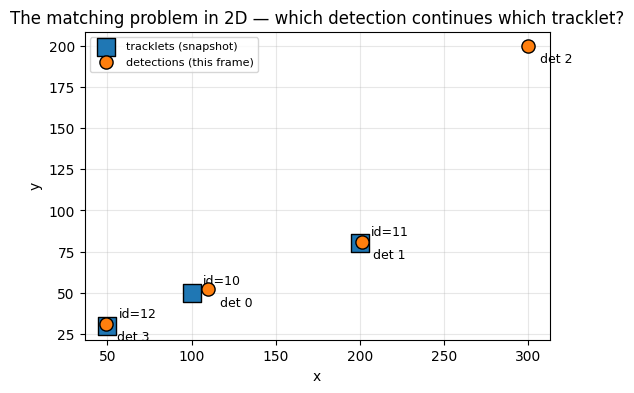

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
tp, dp = t.position, d.position
ax.scatter(
    tp[:, 0],
    tp[:, 1],
    s=160,
    marker="s",
    color="tab:blue",
    edgecolor="black",
    label="tracklets (snapshot)",
    zorder=3,
)
for i in range(t.batch_size[0]):
    ax.annotate(
        f"id={int(t.id[i])}",
        (tp[i, 0], tp[i, 1]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
    )
ax.scatter(
    dp[:, 0],
    dp[:, 1],
    s=90,
    marker="o",
    color="tab:orange",
    edgecolor="black",
    label="detections (this frame)",
    zorder=3,
)
for j in range(d.batch_size[0]):
    ax.annotate(
        f"det {j}",
        (dp[j, 0], dp[j, 1]),
        textcoords="offset points",
        xytext=(8, -12),
        fontsize=9,
    )
ax.set_title("The matching problem in 2D — which detection continues which tracklet?")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()


Detections 0, 1, 3 each sit beside a tracklet; detection 2 (far
top-right) has no nearby tracklet — it should fall through as a
new identity. Keep that picture in mind as we build the cost.

## CostExpression — cost matrix with un-applied gates

After a `CostProducer` runs, it returns a `CostExpression`: an
(N, M) cost matrix together with optional **un-applied** gates
and bias. Carrying the gates separately lets a downstream
node decide *when* to apply them — handy if you want to merge
costs from multiple branches before applying gates.

Below: a simple 3×4 cost matrix (Euclidean distance between
the tracklets' and detections' positions), with no gates yet.


In [7]:
dist = torch.cdist(t.position, d.position, p=2.0)
cost = CostExpression.from_matrix(dist)
print("matrix (lower = closer):")
print(cost.matrix.round(decimals=2))
print(f"\ngates attached: pair={cost.gate_pair}, cs={cost.gate_cs}, ds={cost.gate_ds}")


matrix (lower = closer):
tensor([[ 10.2000, 105.6500, 250.0000,  54.4200],
        [ 94.2500,   1.4100, 156.2000, 158.7500],
        [ 63.9100, 159.3800, 302.3200,   1.4100]])

gates attached: pair=None, cs=None, ds=None


Visualizing the cost matrix as a heatmap makes the structure
obvious: tracklet *i* should match detection *j* where the
cell is dark.


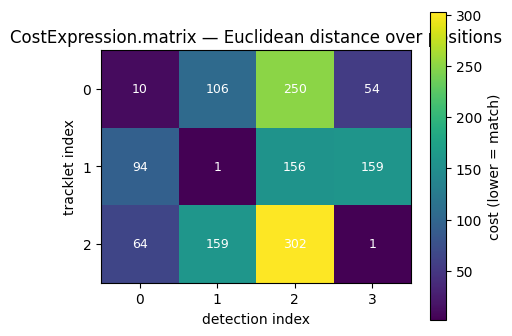

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cost.matrix.numpy(), cmap="viridis")
ax.set_xlabel("detection index")
ax.set_ylabel("tracklet index")
ax.set_title("CostExpression.matrix — Euclidean distance over positions")
ax.set_xticks(range(d.batch_size[0]))
ax.set_yticks(range(t.batch_size[0]))
for i in range(t.batch_size[0]):
    for j in range(d.batch_size[0]):
        ax.text(
            j,
            i,
            f"{cost.matrix[i, j]:.0f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )
plt.colorbar(im, ax=ax, label="cost (lower = match)")
plt.show()


## Gate — algebraic variant for filtering pairs

A `Gate` is a small union type with four constructors:

- `Gate.PerPair(mask: (N, M))` — pairwise boolean accept/reject.
- `Gate.PerCs(mask: (N,))` — drop entire tracklet rows.
- `Gate.PerDs(mask: (M,))` — drop entire detection columns.
- `Gate.CostBias(matrix: (N, M))` — additive cost penalty.

Gates compose under conjunction via `Gate.combine(a, b)` —
cross-kind combinations are promoted to the smallest common
representation (e.g., `PerCs ∧ PerDs → PerPair`).

Below: build a per-pair gate that only allows tracklet *i* to
match detection *j* if their classes agree, then visualize
the gated cost.


In [9]:
# Pretend the user adds a class field to both tracklets and detections.
t_class = torch.tensor([0, 1, 0])  # tracklet classes
d_class = torch.tensor([0, 1, 2, 0])  # detection classes
same_class = t_class[:, None] == d_class[None, :]  # (N, M) bool

gate = Gate.PerPair(mask=same_class)
cost_gated = gate.apply(cost)

# ``materialize`` applies all attached gates to produce a final cost
# matrix where blocked pairs become +inf.
materialized = cost_gated.materialize()
print("After ClassGate (only same-class pairs allowed):")
print(materialized.round(decimals=1))


After ClassGate (only same-class pairs allowed):
tensor([[10.2000,     inf,     inf, 54.4000],
        [    inf,  1.4000,     inf,     inf],
        [63.9000,     inf,     inf,  1.4000]])


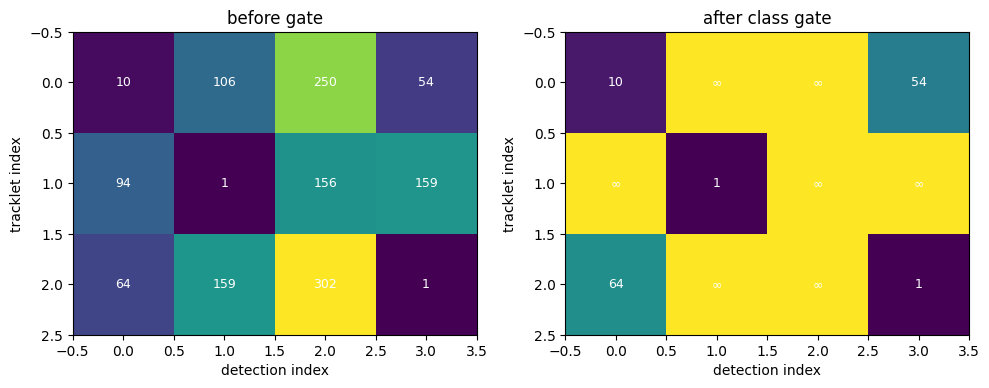

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (m, title) in zip(
    axes, [(cost.matrix, "before gate"), (materialized, "after class gate")]
):
    disp = m.clone()
    disp[torch.isinf(disp)] = m[~torch.isinf(disp)].max() * 2
    im = ax.imshow(disp.numpy(), cmap="viridis")
    ax.set_xlabel("detection index")
    ax.set_ylabel("tracklet index")
    ax.set_title(title)
    for i in range(t.batch_size[0]):
        for j in range(d.batch_size[0]):
            label = "∞" if torch.isinf(m[i, j]) else f"{m[i, j]:.0f}"
            ax.text(j, i, label, ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()


## MatchOutcome — what the associator returns

After running an `Associator` (Jonker, Hungarian, Greedy, …),
you get a `MatchOutcome` that records:

- `matched_pairs`: (K, 2) — `(tracklet_index, detection_index)` rows.
- `tracklets_residual_index`: which tracklets did NOT match.
- `detections_residual_index`: which detections did NOT match.
- `per_match_cost`: per-pair assignment cost (telemetry/HPO).


In [11]:
from unitrack.assignment import Associate, Jonker

m = MatchOutcome.empty()
print(f"empty MatchOutcome: matched_pairs={m.matched_pairs.shape}")

# Build an Associator and run it on the gated cost.
ctx = FrameContext.make(frame_idx=0, delta=0.0)
outcome = Associate(Jonker(threshold=200.0))(t, d, ctx, cost_gated)
print(f"matched_pairs: {outcome.matched_pairs.tolist()}")
print(f"residual tracklets: {outcome.tracklets_residual_index.tolist()}")
print(f"residual detections: {outcome.detections_residual_index.tolist()}")


empty MatchOutcome: matched_pairs=torch.Size([0, 2])
matched_pairs: [[0, 0], [1, 1], [2, 3]]
residual tracklets: []
residual detections: [2]


Reading the matched pairs:

- tracklet 0 (class 0) ↔ detection 0 (class 0)
- tracklet 1 (class 1) ↔ detection 1 (class 1)
- tracklet 2 (class 0) ↔ detection 3 (class 0)

Detection 2 (class 2) had no class-matching tracklet, so it lands
in `detections_residual_index` — ready to be promoted to a brand-
new tracklet by the rest of `Tracker.step`.

## What's next

Notebook **3** visualizes the cost zoo (cosine, IoU, BiSoftmax,
Mahalanobis, …) and the gate zoo (Class, Score, Spatial, Motion)
side by side, showing how each shape fits the algebra above.
